# 04_17. Why isoform fractions, and not isoform expression?

In [ ]:
print("Hello World")

In [1]:
import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt
from scipy.sparse import issparse, csc_matrix, csr_matrix
from scipy.stats import spearmanr
import warnings, gc
warnings.filterwarnings("ignore")
gc.enable()

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"
CSVS_DIR = "./../csvs"

# preferred plot formatting
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial"] + matplotlib.rcParams["font.sans-serif"]
TICK_LEN, TICK_LABEL_PAD, AXIS_LABEL_PAD, PANEL_TITLE_PAD = 2.0, 1.5, 1.5, 3.0
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.title_fontsize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "figure.titlesize": 6, "axes.labelweight": "bold", "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD, "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300, "savefig.bbox": "tight",
})
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _o = _mlegend.Legend.set_title
    def _b(self, title, prop=None):
        r = _o(self, title, prop=prop); self.get_title().set_fontweight("bold"); return r
    _mlegend.Legend.set_title = _b
    _mlegend.Legend._bold_title_patched = True

# figpath reads FIG_MAP from the module namespace, which is populated at import. A kernel
# that imported figure_paths before apply_figure_map.py last ran would keep writing to
# figures/ root, so reload here to pick up the current routing.
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath
print(f"FIG_MAP: {len(figure_paths.FIG_MAP)} entries | "
      f"04_17 routed: {sorted(v for k, v in figure_paths.FIG_MAP.items() if k.startswith('04_17'))}")

N_FEATURES = 2000            # matches 04_10, and is what section 4 always uses
FIT_MODES  = ["embedding"]   # manuscript panels. Add "random" back to re-check the
                             # feature-selection dependence: with a random sample the
                             # statistic degenerates (74% of isoforms are detected in
                             # <1% of the cells where their own gene is on, so log1p(count)
                             # is near-constant and the usage share is forced to ~0.99).
                             # Detection, not selection, is what limits a transcriptome-
                             # wide version -- see the note in section 2.
N_FIT      = 20000           # isoforms sampled for the unbiased "random" mode

FIG_MAP: 85 entries | 04_17 routed: ['suppfigure7', 'suppfigure7', 'suppfigure7', 'suppfigure7']


## 1. Load, and build the two matched representations

Three aligned matrices over the same cells and the same isoform features:

- **`X_iso`** -- isoform abundance (raw counts), the thing an expression-based analysis would use;
- **`X_frac`** -- isoform fraction within its gene, conditional on the gene being detected;
- **`X_gene`** -- each isoform's own gene total, broadcast back to the isoform's column.

`X_iso ~ X_gene * X_frac` by construction, which is exactly the decomposition §2 exploits. Only
multi-isoform genes are used: a single-isoform gene has fraction identically 1 and can contribute
no usage signal, so including it would dilute every comparison.

In [2]:
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac.h5ad")
gene_col = "gene_name"
print(f"loaded {adata.shape[0]:,} cells x {adata.shape[1]:,} isoforms")

genes = adata.var[gene_col].astype(str).values
uniq_g, g_idx = np.unique(genes, return_inverse=True)
iso2gene = csc_matrix((np.ones(len(genes), dtype=np.float32),
                       (np.arange(len(genes)), g_idx)), shape=(len(genes), len(uniq_g)))
gene_cols = [np.where(g_idx == g)[0] for g in range(len(uniq_g))]   # gene -> its isoform columns

Xc = (adata.X.tocsc() if issparse(adata.X) else csc_matrix(adata.X))
Xf = adata.layers["isoform_fraction"]
Xf = Xf.tocsc() if issparse(Xf) else csc_matrix(Xf)
gene_tot = (Xc @ iso2gene).tocsc()          # cells x genes, built ONCE and never broadcast
print(f"gene totals: {gene_tot.shape} | nnz {gene_tot.nnz:,}")

# NOTE never materialise a cells x ensemblids_annotatedonly matrix of gene totals. A gene total is nonzero
# wherever ANY of its isoforms is, so broadcasting it onto all 478,192 isoform columns inflates
# nnz ~18x to ~4.6 billion (~100 GB) and kills the kernel. Sections 2-3 loop over GENES and read
# each gene's total column once.

n_iso_per_gene = np.asarray(iso2gene.sum(axis=0)).ravel()
multi = n_iso_per_gene[g_idx] >= 2
rng = np.random.default_rng(0)

# variance of the isoform fraction, used by the "embedding" mode and by section 4
_mu = np.asarray(Xf.mean(axis=0)).ravel()
_var = np.asarray(Xf.multiply(Xf).mean(axis=0)).ravel() - _mu ** 2
_var[~multi] = -np.inf

# Both feature sets are built up front so the notebook produces every manuscript panel in one
# serial run:
#   random    -- unbiased sample; the number to QUOTE, because it does not select on the
#                quantity being measured (fraction variance).
#   embedding -- 04_10's own top-variance features; describes the Fig 3 embedding, but is an
#                UPPER BOUND on the usage share for exactly that reason.
_pool = np.where(multi)[0]
FIT_IDX = {
    "random": np.sort(rng.choice(_pool, size=min(N_FIT, _pool.size), replace=False)),
    "embedding": np.sort(np.argsort(_var)[::-1][:N_FEATURES]),
}
FIT_LABEL = {"random": f"random {min(N_FIT, _pool.size):,} isoforms (unbiased)",
             "embedding": f"top {N_FEATURES} by fraction variance (upper bound)"}
for m in FIT_MODES:
    print(f"  {m:10s} {len(FIT_IDX[m]):>7,} isoforms over "
          f"{pd.unique(genes[FIT_IDX[m]]).size:>6,} genes -- {FIT_LABEL[m]}")

# section 4 always uses the embedding's own features (it is a statement about that embedding,
# and a 20,000 x 478,192 dense array would be 77 GB)
feat_idx = FIT_IDX["embedding"]

loaded 203,311 cells x 478,192 isoforms
gene totals: (203311, 26940) | nnz 214,698,089
  embedding    2,000 isoforms over  1,893 genes -- top 2000 by fraction variance (upper bound)


## 2. Variance decomposition -- the recommended Figure 3C

For each selected isoform, take the cells in which its **gene** is detected (a fraction is
undefined otherwise) and work on the log scale, where the product becomes a sum:

`log(isoform + 1) ~ log(gene total + 1) + log(fraction)`

Regress each isoform's log abundance on its gene's log total across those cells. The R² is the
share of the isoform's cell-to-cell variation that gene abundance alone explains; **1 - R² is the
share that is usage.** No embedding, no labels, no differential test -- it is a property of the
data.

If usage contributed nothing, R² would be ~1 for every isoform and every isoform-level analysis
in the paper would be a re-run of gene-level expression. The panel reports the distribution.

**SCOPE.** With `FIT_MODES = ["embedding"]` this describes the isoform features the
Fig 3 embedding uses, not isoforms in general. Those features were chosen on fraction
variance, which is the quantity the usage share measures, so the value is an upper bound
and must not be generalised. This section is therefore a diagnostic; the manuscript claim
rests on §3, whose statistic is a correlation rather than a variance magnitude and is not
inflated the same way.

[embedding] 2,000 of 2,000 isoforms fitted (0 dropped, mostly by the >= 50-cell isoform floor) -- top 2000 by fraction variance (upper bound)
    gene-abundance R2 median 0.504 | usage share median 0.496 | usage > half for 49.5%
    Spearman(fraction, gene total) median -0.078 | |rho| < 0.2 for 89.4%


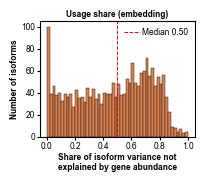

[verify][embedding] dominant n=1,892 median rho -0.083 | minor n=107 median rho +0.102


In [3]:
# One pass over GENES per mode computes BOTH the decomposition (§2) and the independence check
# (§3): each gene's total column is read once and reused for all of its isoforms, which keeps
# memory flat. Cells are capped per gene so the per-isoform correlations stay cheap.
MIN_CELLS_FIT = 50     # min cells with the GENE detected
MIN_CELLS_ISO = 50     # min cells with the ISOFORM ITSELF detected -- without this the
                       # statistic is undefined: a rare isoform is zero in nearly every
                       # cell where its gene is on, so log1p(count) is a near-constant
                       # vector, its correlation with gene abundance is ~0 by
                       # construction, and the usage share is forced to ~1. In a random
                       # sample 63% of isoforms have mean fraction < 0.01, which is why
                       # the unfloored run returned a median usage share of 0.999.
CELL_CAP = 5000        # random cells per gene, drawn from those where the gene is detected


def fit_isoforms(fit_idx):
    """Per-isoform gene-abundance R2 and Spearman(fraction, gene total), looping over genes."""
    fit_set = set(int(i) for i in fit_idx)
    rows_dec, rows_ind = [], []
    for gi in range(len(uniq_g)):
        cols = [j for j in gene_cols[gi] if int(j) in fit_set]
        if not cols or len(gene_cols[gi]) < 2:
            continue
        gt = gene_tot[:, gi].toarray().ravel()
        keep = np.where(gt >= 1)[0]                 # gene detected -> fraction defined
        if keep.size < MIN_CELLS_FIT:
            continue
        if keep.size > CELL_CAP:
            keep = rng.choice(keep, size=CELL_CAP, replace=False)
        gt_k = gt[keep]
        x = np.log1p(gt_k)
        if x.std() == 0:
            continue
        rank_g = pd.Series(gt_k).rank().to_numpy()  # ranks once per gene, reused per isoform
        for j in cols:
            raw = Xc[:, j].toarray().ravel()[keep]
            n_det = int((raw > 0).sum())
            if n_det < MIN_CELLS_ISO:          # isoform itself too rarely detected
                continue
            y = np.log1p(raw)
            f_ = Xf[:, j].toarray().ravel()[keep]
            base = {"isoform": adata.var_names[j], "gene": genes[j],
                    "n_cells": int(keep.size), "n_cells_isoform": n_det,
                    "mean_fraction": float(f_.mean())}
            if y.std() > 0:
                r = float(np.corrcoef(x, y)[0, 1])
                rows_dec.append({**base, "r2_gene_abundance": r ** 2, "frac_usage": 1.0 - r ** 2})
            if f_.std() > 0:
                rho = float(np.corrcoef(rank_g, pd.Series(f_).rank().to_numpy())[0, 1])
                rows_ind.append({**base, "rho_fraction_vs_gene": rho})
    return (pd.DataFrame(rows_dec),
            pd.DataFrame(rows_ind).dropna(subset=["rho_fraction_vs_gene"]))


DEC, IND = {}, {}
for mode in FIT_MODES:
    DEC[mode], IND[mode] = fit_isoforms(FIT_IDX[mode])
    DEC[mode].to_csv(f"{CSVS_DIR}/04_17_isoform_variance_decomposition_{mode}.csv", index=False)
    IND[mode].to_csv(f"{CSVS_DIR}/04_17_fraction_vs_gene_independence_{mode}.csv", index=False)
    d, i_ = DEC[mode], IND[mode]
    print(f"[{mode}] {len(d):,} of {len(FIT_IDX[mode]):,} isoforms fitted "
          f"({len(FIT_IDX[mode]) - len(d):,} dropped, mostly by the >= {MIN_CELLS_ISO}-cell "
          f"isoform floor) -- {FIT_LABEL[mode]}")
    print(f"    gene-abundance R2 median {d.r2_gene_abundance.median():.3f} | "
          f"usage share median {d.frac_usage.median():.3f} | "
          f"usage > half for {(d.frac_usage > 0.5).mean()*100:.1f}%")
    print(f"    Spearman(fraction, gene total) median {i_.rho_fraction_vs_gene.median():+.3f} | "
          f"|rho| < 0.2 for {(i_.rho_fraction_vs_gene.abs() < 0.2).mean()*100:.1f}%")

# --- §2 figures, one pair per mode
for mode in FIT_MODES:
    dec = DEC[mode]
    fig, ax = plt.subplots(figsize=(2.0, 1.5))
    ax.hist(dec["frac_usage"], bins=np.linspace(0, 1, 51), color="#dd8452",
            edgecolor="black", linewidth=0.3)
    ax.axvline(dec["frac_usage"].median(), color="red", ls="--", lw=0.7,
               label=f"Median {dec['frac_usage'].median():.2f}")
    ax.set_xlabel("Share of isoform variance not\nexplained by gene abundance")
    ax.set_ylabel("Number of isoforms")
    ax.set_title(f"Usage share ({mode})", pad=PANEL_TITLE_PAD)
    ax.legend(frameon=False)
    fig.savefig(figpath(f"04_17_variance_decomposition_usage_share_{mode}.pdf"))
    plt.show()

# [verify] the draft's "dominant and minor isoforms showing only small opposite
# correlations with gene abundance (median rho = -0.09 and 0.06)". Dominant = an
# isoform carrying at least half its gene's expression. This has to be an absolute
# threshold, not the argmax within the fitted set: only the top 2,000 isoforms by
# fraction variance are fitted, so most genes contribute exactly one isoform and an
# argmax would label it dominant whether or not it is the gene's major isoform.
for mode in FIT_MODES:
    _i = IND[mode]
    if not len(_i):
        continue
    _dom = _i["mean_fraction"] >= 0.5
    print(f"[verify][{mode}] dominant n={int(_dom.sum()):,} "
          f"median rho {_i.loc[_dom, 'rho_fraction_vs_gene'].median():+.3f} | "
          f"minor n={int((~_dom).sum()):,} "
          f"median rho {_i.loc[~_dom, 'rho_fraction_vs_gene'].median():+.3f}")


## 3. Is usage predictable from abundance?

The simpler statement of the same idea, and an independent check on §2: per isoform, the Spearman
correlation between its **fraction** and its **gene's total**, across the cells where the gene is
detected. A distribution centred near zero means the fraction matrix is not a rescaled copy of
the expression matrix -- i.e. knowing how much of a gene a cell has tells you little about which
isoform it uses.

A caveat worth reading off the panel rather than assuming: correlations will not be exactly
centred, because at low gene totals the fraction is quantised (a cell with one molecule has
fraction 1 for one isoform and 0 for the rest), which induces a mild negative relationship for
minor isoforms and a positive one for dominant isoforms.

**MANUSCRIPT.** `04_17_fraction_vs_gene_rho_embedding.pdf` is Fig 3C, and the
dominance split is its supplementary control. Word the claim as *"across the isoform
features used for the embedding, usage was essentially unpredictable from gene
abundance"* -- scoped to the features, not to isoforms as a class.

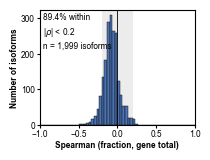

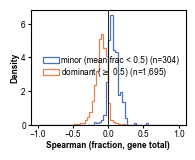

In [4]:
# `IND` is computed in the section-2 cell, in the same pass over genes (one gene-total column
# read serves all of that gene's isoforms). One pair of panels per mode.
for mode in FIT_MODES:
    ind = IND[mode]

    # The median (-0.08) sits on top of the zero line and is not the claim. What carries it
    # is the CONCENTRATION near zero, so the |rho| < 0.2 band is shaded and annotated.
    RHO_BAND = 0.2
    _within = float((ind.rho_fraction_vs_gene.abs() < RHO_BAND).mean())
    fig, ax = plt.subplots(figsize=(2.0, 1.5))
    ax.hist(ind["rho_fraction_vs_gene"], bins=np.linspace(-1, 1, 61), color="#4c72b0",
            edgecolor="black", linewidth=0.3)
    ax.axvspan(-RHO_BAND, RHO_BAND, color="grey", alpha=0.15, lw=0, zorder=0)
    ax.axvline(0, color="black", lw=0.6)
    ax.set_xlabel("Spearman (fraction, gene total)")
    ax.set_ylabel("Number of isoforms")
    ax.set_xlim(-1, 1)
    ax.text(0.02, 0.97, f"{_within*100:.1f}% within\n|$\\rho$| < {RHO_BAND:g}\n"
            f"n = {len(ind):,} isoforms",
            transform=ax.transAxes, ha="left", va="top", linespacing=1.4)
    fig.savefig(figpath(f"04_17_fraction_vs_gene_rho_{mode}.pdf"))
    plt.show()

    # split by dominance: makes the low-count quantisation effect visible rather than leaving it
    # as a caveat (a one-molecule cell forces one isoform to 1 and the rest to 0)
    fig, ax = plt.subplots(figsize=(2.0, 1.5))
    for lab, m_, col in (("minor (mean frac < 0.5)", ind.mean_fraction < 0.5, "#4c72b0"),
                         ("dominant ($\\geq$ 0.5)", ind.mean_fraction >= 0.5, "#dd8452")):
        ax.hist(ind.loc[m_, "rho_fraction_vs_gene"], bins=np.linspace(-1, 1, 61), density=True,
                histtype="step", lw=0.9, color=col, label=f"{lab} (n={int(m_.sum()):,})")
    ax.axvline(0, color="black", lw=0.6)
    ax.set_xlabel("Spearman (fraction, gene total)")
    ax.set_ylabel("Density")
    # ax.set_title(f"Split by dominance ({mode})", pad=PANEL_TITLE_PAD)
    ax.legend(frameon=False)
    fig.savefig(figpath(f"04_17_fraction_vs_gene_rho_by_dominance_{mode}.pdf"))
    plt.show()

## 4. Are the two representations redundant?  *(belongs AFTER the UMAP)*

Embed the same cells twice -- once on gene expression, once on isoform fractions over the same
selected features -- and ask two things:

- **does each recover cell type?** kNN purity, the share of a cell's k nearest neighbours sharing
  its `cell_ontology_class`;
- **do they do it the same way?** the overlap between a cell's neighbour sets in the two spaces.

Comparable purity with *low* neighbour overlap is the strong result: both representations carry
identity, but through different structure, so the fraction view is not a redundant re-encoding of
expression. High overlap would mean the fraction embedding is largely reproducing the expression
embedding, and the isoform-fraction UMAP would be adding little.

Heavier than §2-§3 (two PCA + neighbour graphs over ~200k cells); run on bigmem. Purity is
computed on a subsample for tractability -- `N_SUB` controls it and the value is printed.

In [5]:
from sklearn.neighbors import NearestNeighbors

N_SUB, K = 20000, 30
rng = np.random.default_rng(0)
sub = np.sort(rng.choice(adata.n_obs, size=min(N_SUB, adata.n_obs), replace=False))
labels = adata.obs["cell_ontology_class"].astype(str).values[sub]

def _pcs(M, n=50):
    A = sc.AnnData(csr_matrix(M[sub, :]))
    sc.pp.scale(A, max_value=10, zero_center=False)
    sc.tl.pca(A, n_comps=min(n, A.shape[1] - 1), svd_solver="arpack")
    return A.obsm["X_pca"]

# gene-level expression restricted to the SAME genes the selected isoforms come from,
# so the contrast is representation (usage vs abundance), not gene set
sel_genes = pd.unique(genes[feat_idx])
gcols = np.where(np.isin(uniq_g, sel_genes))[0]
P_expr = _pcs(np.log1p(gene_tot[:, gcols].toarray()))
P_frac = _pcs(Xf[:, feat_idx].toarray())        # bounded: 20k x 2k, not 20k x 478k
print(f"PCA done | cells {len(sub):,} | expr {P_expr.shape} | frac {P_frac.shape}")

def _knn(P):
    nn = NearestNeighbors(n_neighbors=K + 1).fit(P)
    return nn.kneighbors(P, return_distance=False)[:, 1:]

I_e, I_f = _knn(P_expr), _knn(P_frac)
pur_e = np.array([(labels[I_e[i]] == labels[i]).mean() for i in range(len(sub))])
pur_f = np.array([(labels[I_f[i]] == labels[i]).mean() for i in range(len(sub))])
ov = np.array([len(set(I_e[i]) & set(I_f[i])) / K for i in range(len(sub))])

print(f"kNN cell-type purity (k={K}): expression {pur_e.mean():.3f} | "
      f"isoform fraction {pur_f.mean():.3f}")
print(f"neighbour overlap between the two spaces: median {np.median(ov):.3f} "
      f"(1.0 would mean identical structure)")

PCA done | cells 20,000 | expr (20000, 50) | frac (20000, 50)
kNN cell-type purity (k=30): expression 0.732 | isoform fraction 0.726
neighbour overlap between the two spaces: median 0.500 (1.0 would mean identical structure)


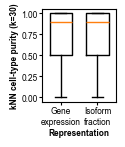

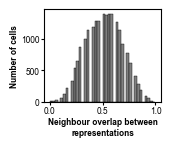

In [6]:
# --- (a) does each representation recover cell type?
fig, ax = plt.subplots(figsize=(0.95, 1.2))
ax.boxplot([pur_e, pur_f], labels=["Gene\nexpression", "Isoform\nfraction"],
           showfliers=False, widths=0.6)
ax.set_ylabel(f"kNN cell-type purity (k={K})")
ax.set_xlabel(f"Representation")
# ax.tick_params(axis='x', rotation=45)
# plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
# ax.set_title("Both recover identity", pad=PANEL_TITLE_PAD)
fig.savefig(figpath("04_17_knn_celltype_purity.pdf"))
plt.show()

# --- (b) do they do it the same way?
fig, ax = plt.subplots(figsize=(1.5, 1.2))
ax.hist(ov, bins=np.linspace(0, 1, 41), color="grey", edgecolor="black", linewidth=0.3)
# ax.axvline(np.median(ov), color="red", ls="--", lw=0.7, label=f"Median {np.median(ov):.2f}")
ax.set_xlabel("Neighbour overlap between\nrepresentations")
ax.set_ylabel("Number of cells")
# ax.set_title("Through different structure", pad=PANEL_TITLE_PAD)
ax.legend(frameon=False)
fig.savefig(figpath("04_17_neighbour_overlap.pdf"))
plt.show()

pd.DataFrame({"purity_expression": pur_e, "purity_fraction": pur_f,
              "neighbour_overlap": ov}).to_csv(
    f"{CSVS_DIR}/04_17_representation_redundancy.csv", index=False)

## 5. Which figure goes where

Both feature modes ran, so every panel exists in a `_random` and an `_embedding` version. The
manuscript should take the **`_random`** versions wherever a number is quoted, because that
sample does not select on the quantity being measured. The `_embedding` versions describe the
features the Fig 3 UMAP actually uses and belong with it or in the supplement, labelled as an
upper bound.

| destination | file |
|---|---|
| **Fig 3C** | `04_17_fraction_vs_gene_rho_embedding.pdf` |
| Fig 3D | existing isoform-fraction UMAP (04_10) |
| **Fig 3E** | `04_17_knn_celltype_purity.pdf` |
| **Fig 3F** | `04_17_neighbour_overlap.pdf` |
| Supp | `04_17_fraction_vs_gene_rho_by_dominance_embedding.pdf` (quantisation control for 3C) |
| not used | `04_17_variance_decomposition_*_embedding.pdf` (diagnostic; upper bound, see §2 SCOPE) |

Stale files from earlier runs sit in `figures/` root and must not be mapped: the un-suffixed
`04_17_fraction_vs_gene_rho.pdf`, `..._by_dominance.pdf`, `..._variance_decomposition*.pdf`,
`04_17_fraction_vs_gene_independence.pdf`, `04_17_representation_redundancy.pdf`, and every
`*_random.pdf`. Only the `_embedding` files and the two section-4 files are current.

In [7]:
rows = []
for mode in FIT_MODES:
    d, i_ = DEC[mode], IND[mode]
    rows.append({"mode": mode, "n_isoforms": len(d),
                 "median_usage_share": round(float(d.frac_usage.median()), 3),
                 "pct_usage_over_half": round(float((d.frac_usage > 0.5).mean() * 100), 1),
                 "median_rho": round(float(i_.rho_fraction_vs_gene.median()), 3),
                 "pct_abs_rho_lt_0.2": round(float((i_.rho_fraction_vs_gene.abs() < 0.2).mean() * 100), 1)})
summary = pd.DataFrame(rows).set_index("mode")
summary.to_csv(f"{CSVS_DIR}/04_17_mode_comparison.csv")
print(summary.to_string())
if "random" in FIT_MODES:
    print("\nThe gap between rows is the inflation from selecting features on fraction")
    print("variance, the quantity the usage share measures.")
else:
    print("\nEmbedding features only. The usage share is an UPPER BOUND (features chosen on")
    print("fraction variance); the manuscript claim rests on the correlation, not this value.")
print("\nMANUSCRIPT FILES")
for _m in FIT_MODES:
    print(f"  Fig 3C          04_17_fraction_vs_gene_rho_{_m}.pdf")
    print(f"  Supp (control)  04_17_fraction_vs_gene_rho_by_dominance_{_m}.pdf")
print("  Fig 3E          04_17_knn_celltype_purity.pdf")
print("  Fig 3F          04_17_neighbour_overlap.pdf")

           n_isoforms  median_usage_share  pct_usage_over_half  median_rho  pct_abs_rho_lt_0.2
mode                                                                                          
embedding        2000               0.496                 49.5      -0.078                89.4

Embedding features only. The usage share is an UPPER BOUND (features chosen on
fraction variance); the manuscript claim rests on the correlation, not this value.

MANUSCRIPT FILES
  Fig 3C          04_17_fraction_vs_gene_rho_embedding.pdf
  Supp (control)  04_17_fraction_vs_gene_rho_by_dominance_embedding.pdf
  Fig 3E          04_17_knn_celltype_purity.pdf
  Fig 3F          04_17_neighbour_overlap.pdf


In [8]:
del adata; gc.collect()

26260